Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 46 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

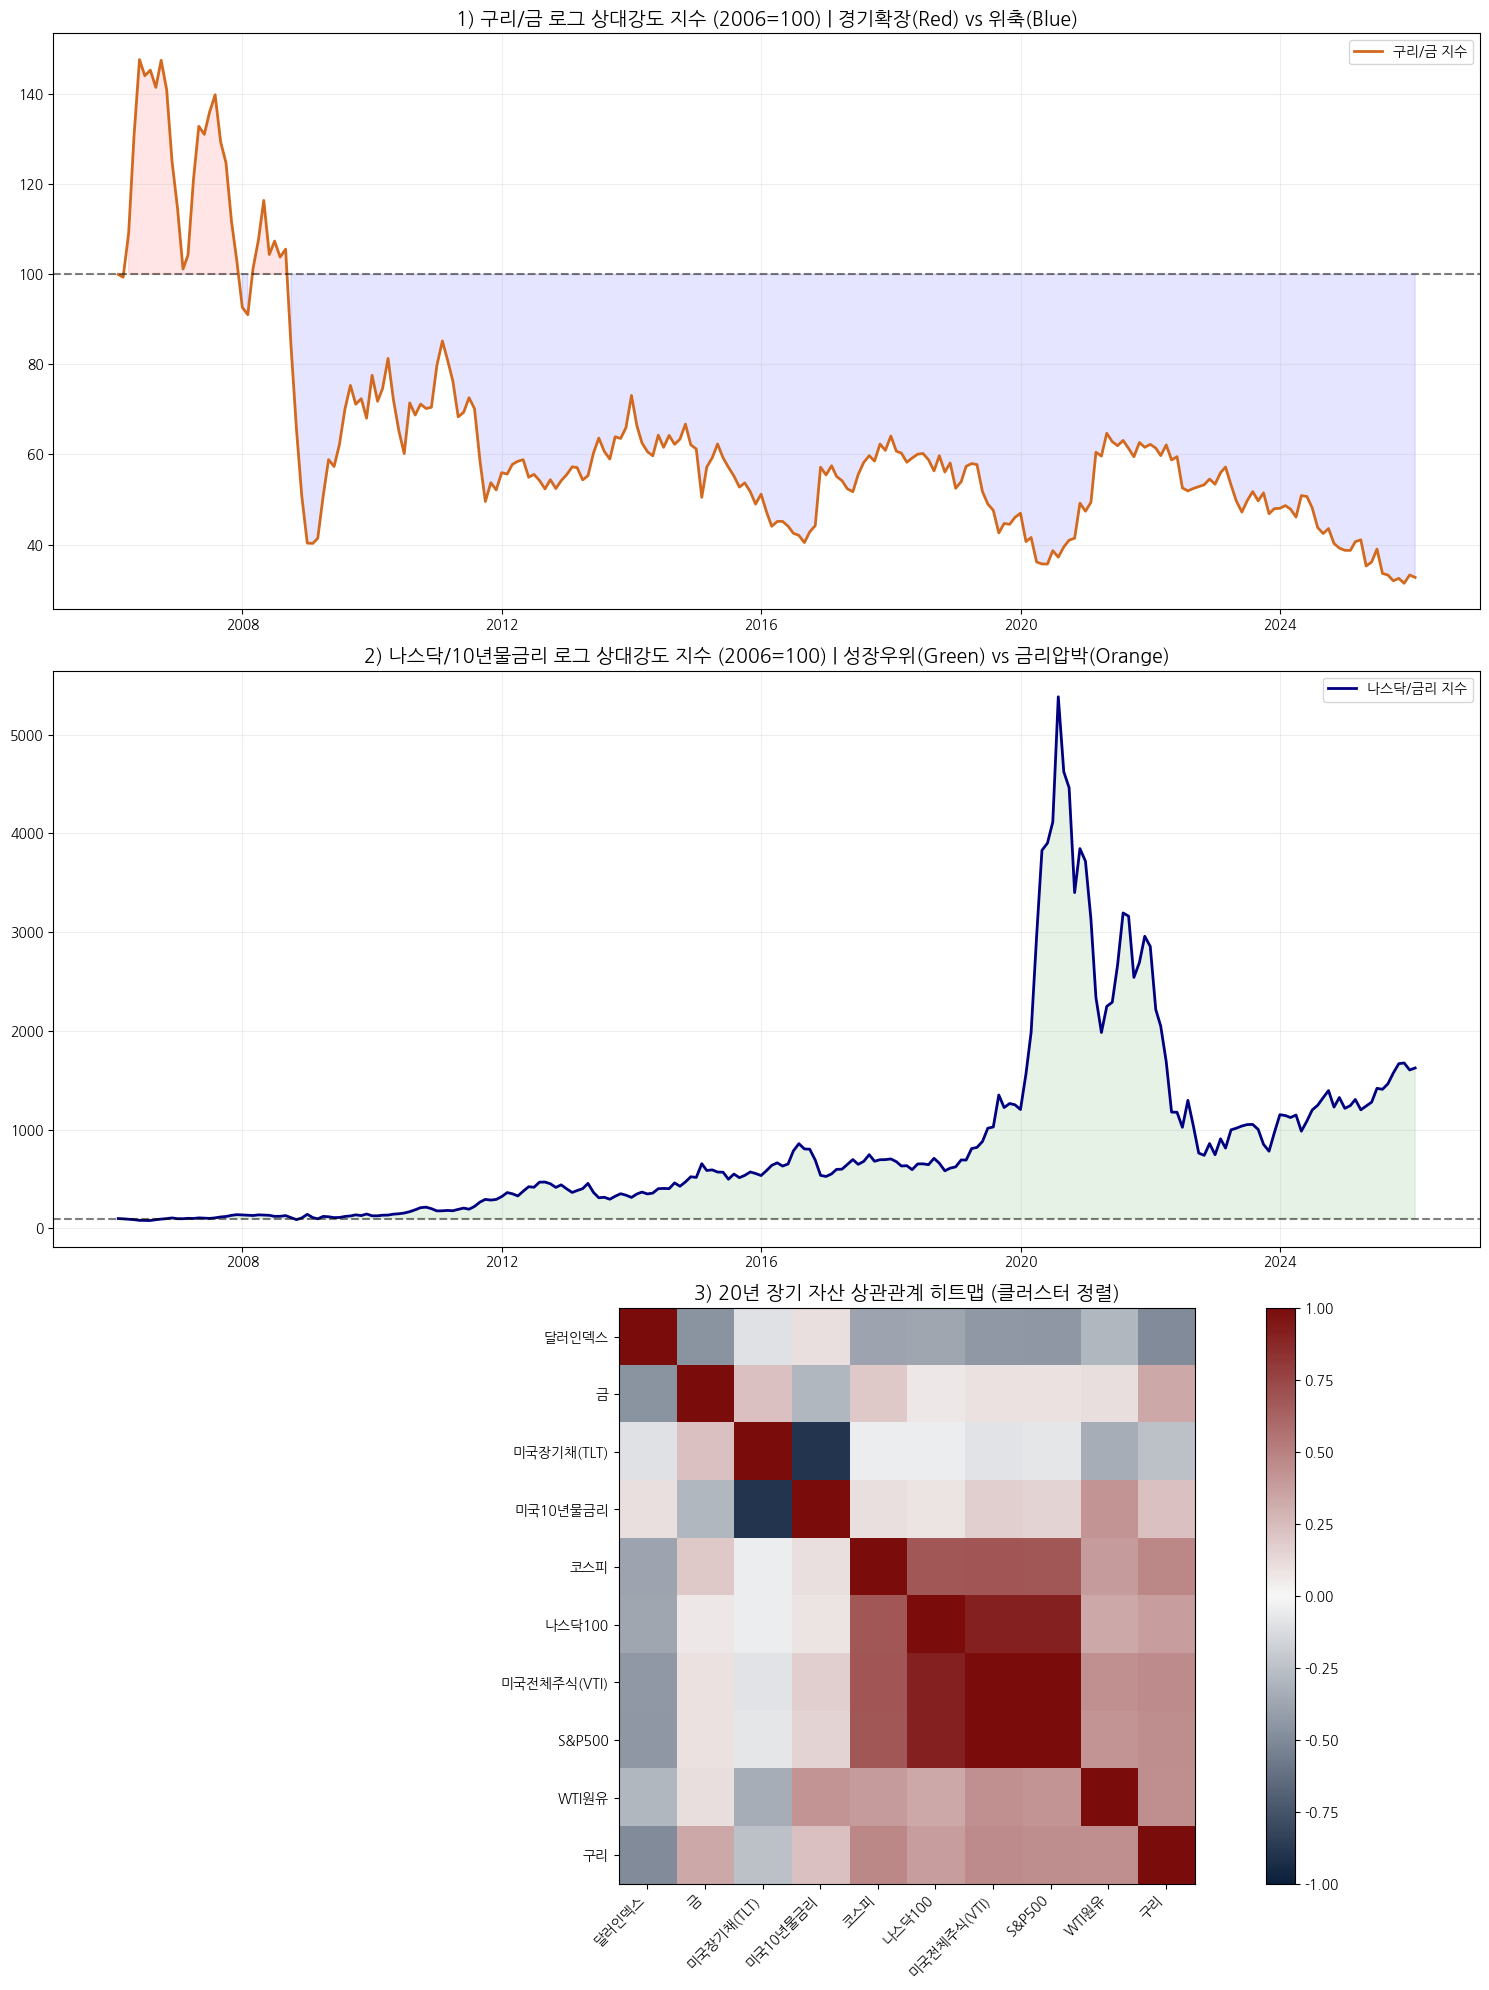


【 20년 장기 매크로 및 상관분석 리포트 ( 2006-01-01 ~ 현재 ) 】
▶ [상대강도 진단]
 - 구리/금 지수: 32.70 -> 경기 위축기: 금/안전지산 우세
 - 나스닥/금리 지수: 1625.07 -> 기술주 장세: 성장성이 금리비용 압도

▶ [자산 간 상관성 요약]
 - 가장 비슷하게 움직이는 쌍:
   * S&P500 & 미국전체주식(VTI): 1.00
   * 나스닥100 & S&P500: 0.91
   * 미국전체주식(VTI) & 나스닥100: 0.91
 - 가장 반대로 움직이는 쌍(헤지):
   * 미국장기채(TLT) & 미국10년물금리: -0.89
   * 미국10년물금리 & 미국장기채(TLT): -0.89
   * 구리 & 달러인덱스: -0.49

【 실무적 결론 】
1. 구리/금 지수가 100 아래에서 턴어라운드 할 때가 역사적으로 주식 비중을 늘릴 적기였습니다.
2. 나스닥/금리 지수의 급락은 기술주의 멀티플 하락을 예고하므로 포트폴리오 방어가 필요합니다.
3. 히트맵에서 '파란색'인 자산(예: 달러 vs 주식, 금 vs 금리)을 섞는 것이 분산 투자의 핵심입니다.


In [6]:
# =========================================================
# [최종본] 20년 장기 상관관계 + 구리/금 & 나스닥/금리 상대강도 분석
# - 요청사항: 20년 기간, 로그 차분 기반 100 시작 지수, 분석결과 프린트
# =========================================================

!pip -q install yfinance finance-datareader pandas numpy matplotlib scipy

# 한글 폰트 설정
!sudo apt-get -y install fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# 0) 환경 설정
# -----------------------------
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

시작일 = "2006-01-01"
종료일 = "2026-12-31"
리샘플 = "M"

# 실무형 Diverging 컬러맵
실무_컬러맵 = LinearSegmentedColormap.from_list("pro_div", ["#0B1F3B", "#F7F7F7", "#7A0C0C"], N=256)

# -----------------------------
# 1) 유니버스 (20년 데이터가 보장되는 핵심 지수/ETF)
# -----------------------------
유니버스 = {
    "구리": "HG=F",
    "금": "GC=F",
    "나스닥100": "^NDX",
    "미국10년물금리": "^TNX",
    "S&P500": "^GSPC",
    "달러인덱스": "DX-Y.NYB",
    "WTI원유": "CL=F",
    "코스피": "^KS11",
    "미국장기채(TLT)": "TLT",
    "미국전체주식(VTI)": "VTI"
}

# -----------------------------
# 2) 데이터 로드 및 전처리
# -----------------------------
print(f"20년치 데이터 로딩 중... ({시작일} ~ {종료일})")
df = yf.download(list(유니버스.values()), start=시작일, end=종료일, progress=False)['Close']
df.columns = [list(유니버스.keys())[list(유니버스.values()).index(c)] for c in df.columns]
df = df.ffill().dropna()

# 월봉 리샘플링
df_m = df.resample(리샘플).last()

# -----------------------------
# 3) 상대 강도 지수 계산 (요청하신 log(A)-log(B) 누적 방식)
# -----------------------------
def get_rs_index(p_df, asset_a, asset_b):
    # 로그 수익률의 차이: log(A_t/A_t-1) - log(B_t/B_t-1)
    # 이는 log((A_t/B_t) / (A_t-1/B_t-1))와 같음
    log_ret_diff = np.log(p_df[asset_a]/p_df[asset_a].shift(1)) - np.log(p_df[asset_b]/p_df[asset_b].shift(1))
    # 누적 합산 후 지수화하여 시작점을 100으로 고정
    return np.exp(log_ret_diff.fillna(0).cumsum()) * 100

rs_data = pd.DataFrame(index=df_m.index)
rs_data['구리_금_지수'] = get_rs_index(df_m, '구리', '금')
rs_data['나스닥_금리_지수'] = get_rs_index(df_m, '나스닥100', '미국10년물금리')

# -----------------------------
# 4) 상관관계 분석
# -----------------------------
로그수익률 = np.log(df_m / df_m.shift(1)).dropna()
상관 = 로그수익률.corr()

# 클러스터 정렬
Z = linkage(squareform(((1 - 상관) / 2).clip(0, 1)), method="average")
정렬순서 = leaves_list(Z)
상관_정렬 = 상관.iloc[정렬순서, 정렬순서]

# -----------------------------
# 5) 시각화
# -----------------------------
fig = plt.figure(figsize=(15, 20))

# [Chart 1] 구리/금 상대강도
ax1 = plt.subplot(3, 1, 1)
ax1.plot(rs_data.index, rs_data['구리_금_지수'], color='chocolate', lw=2, label='구리/금 지수')
ax1.axhline(100, color='black', ls='--', alpha=0.5)
ax1.fill_between(rs_data.index, 100, rs_data['구리_금_지수'], where=(rs_data['구리_금_지수'] >= 100), color='red', alpha=0.1)
ax1.fill_between(rs_data.index, 100, rs_data['구리_금_지수'], where=(rs_data['구리_금_지수'] < 100), color='blue', alpha=0.1)
ax1.set_title("1) 구리/금 로그 상대강도 지수 (2006=100) | 경기확장(Red) vs 위축(Blue)", fontsize=14)
ax1.grid(True, alpha=0.2)
ax1.legend()

# [Chart 2] 나스닥/금리 상대강도
ax2 = plt.subplot(3, 1, 2)
ax2.plot(rs_data.index, rs_data['나스닥_금리_지수'], color='navy', lw=2, label='나스닥/금리 지수')
ax2.axhline(100, color='black', ls='--', alpha=0.5)
ax2.fill_between(rs_data.index, 100, rs_data['나스닥_금리_지수'], where=(rs_data['나스닥_금리_지수'] >= 100), color='green', alpha=0.1)
ax2.fill_between(rs_data.index, 100, rs_data['나스닥_금리_지수'], where=(rs_data['나스닥_금리_지수'] < 100), color='orange', alpha=0.1)
ax2.set_title("2) 나스닥/10년물금리 로그 상대강도 지수 (2006=100) | 성장우위(Green) vs 금리압박(Orange)", fontsize=14)
ax2.grid(True, alpha=0.2)
ax2.legend()

# [Chart 3] 히트맵
ax3 = plt.subplot(3, 1, 3)
im = ax3.imshow(상관_정렬.values, vmin=-1, vmax=1, cmap=실무_컬러맵)
ax3.set_xticks(np.arange(len(상관_정렬.columns)))
ax3.set_yticks(np.arange(len(상관_정렬.index)))
ax3.set_xticklabels(상관_정렬.columns, rotation=45, ha='right')
ax3.set_yticklabels(상관_정렬.index)
ax3.set_title("3) 20년 장기 자산 상관관계 히트맵 (클러스터 정렬)", fontsize=14)
plt.colorbar(im, ax=ax3)

plt.tight_layout()
plt.show()

# -----------------------------
# 6) 분석 결과 자동 프린트 (요청사항)
# -----------------------------
print("\n" + "="*80)
print(f"【 20년 장기 매크로 및 상관분석 리포트 ( {시작일} ~ 현재 ) 】")
print("="*80)

# 상대강도 현재값 분석
curr_cg = rs_data['구리_금_지수'].iloc[-1]
curr_nt = rs_data['나스닥_금리_지수'].iloc[-1]

print(f"▶ [상대강도 진단]")
print(f" - 구리/금 지수: {curr_cg:.2f} -> {'경기 확장기: 원자재/위험자산 우세' if curr_cg > 100 else '경기 위축기: 금/안전지산 우세'}")
print(f" - 나스닥/금리 지수: {curr_nt:.2f} -> {'기술주 장세: 성장성이 금리비용 압도' if curr_nt > 100 else '가치/채권 장세: 금리 부담이 성장성 압도'}")

# 상관관계 분석
print(f"\n▶ [자산 간 상관성 요약]")
top_corr = 상관.unstack().sort_values(ascending=False).drop_duplicates()
top_corr = top_corr[top_corr < 1.0].head(3)
bottom_corr = 상관.unstack().sort_values(ascending=True).head(3)

print(" - 가장 비슷하게 움직이는 쌍:")
for idx, val in top_corr.items(): print(f"   * {idx[0]} & {idx[1]}: {val:.2f}")

print(" - 가장 반대로 움직이는 쌍(헤지):")
for idx, val in bottom_corr.items(): print(f"   * {idx[0]} & {idx[1]}: {val:.2f}")

print("\n" + "="*80)
print("【 실무적 결론 】")
print("="*80)
print("1. 구리/금 지수가 100 아래에서 턴어라운드 할 때가 역사적으로 주식 비중을 늘릴 적기였습니다.")
print("2. 나스닥/금리 지수의 급락은 기술주의 멀티플 하락을 예고하므로 포트폴리오 방어가 필요합니다.")
print("3. 히트맵에서 '파란색'인 자산(예: 달러 vs 주식, 금 vs 금리)을 섞는 것이 분산 투자의 핵심입니다.")
print("="*80)